In [2]:
import pandas as pd

df = pd.read_csv("instagram_usage_lifestyle.csv")
print(df.head())
print(df.columns)

   user_id   app_name  age      gender         country urban_rural  \
0        1  Instagram   51      Female           India       Rural   
1        2  Instagram   64      Female  United Kingdom       Urban   
2        3  Instagram   41      Female          Canada       Urban   
3        4  Instagram   27  Non-binary     South Korea       Urban   
4        5  Instagram   55        Male           India       Urban   

   income_level   employment_status education_level relationship_status  ...  \
0          High             Retired      Bachelor’s              Single  ...   
1        Middle  Full-time employed           Other            Divorced  ...   
2        Middle             Student      Bachelor’s   In a relationship  ...   
3        Middle          Unemployed        Master’s   In a relationship  ...   
4  Upper-middle  Full-time employed      Bachelor’s              Single  ...   

  last_login_date  average_session_length_minutes  content_type_preference  \
0      2025-11-02   

In [4]:
df

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547891,1547892,Instagram,61,Female,United States,Suburban,High,Full-time employed,Master’s,Widowed,...,2025-01-14,15.8,Videos,Other,Friends only,Yes,Yes,4,Free,0.97
1547892,1547893,Instagram,42,Male,United States,Urban,Lower-middle,Full-time employed,Master’s,Divorced,...,2025-08-04,38.0,Photos,Art,Private,No,No,1,Premium,1.32
1547893,1547894,Instagram,32,Male,Canada,Urban,Low,Full-time employed,Master’s,Single,...,2025-04-10,31.8,Live,Other,Private,Yes,Yes,5,Free,1.01
1547894,1547895,Instagram,14,Female,Other,Urban,Low,Student,Bachelor’s,Single,...,2025-03-21,23.6,Live,Tech,Private,Yes,No,3,Free,1.11


In [6]:
df["employment_status"] = df["employment_status"].map({
    "Retired": 3,
    "Full-time employed": 2,
    "Student":0,
    "Unemployed":1})
    

In [9]:
df["relationship_status"] = df["relationship_status"].map({
    "Single":0,
    "In a relationship":1,
    "Divorced":2,
    "Widowed":3})

In [15]:
df["education_level"] = df["education_level"].map({
    "Bachelor's":2,
    "Other":0,
    "High school":1,
    "Master's":4,
    "Some college":3,
    "PhD":5})

In [13]:
df.nunique()

user_id                           1547896
app_name                                1
age                                    53
gender                                  4
country                                10
urban_rural                             3
income_level                            5
employment_status                       4
education_level                         6
relationship_status                     4
has_children                            2
exercise_hours_per_week               241
sleep_hours_per_night                  71
diet_quality                            5
smoking                                 3
alcohol_frequency                       5
perceived_stress_score                 41
self_reported_happiness                10
body_mass_index                       286
blood_pressure_systolic                70
blood_pressure_diastolic               40
daily_steps_count                     773
weekly_work_hours                     800
hobbies_count                     

In [43]:
X = df[[
    "exercise_hours_per_week",
    "sleep_hours_per_night",
    "age",
    "sessions_per_day",
    "reels_watched_per_day",
    "likes_given_per_day",
    "stories_viewed_per_day",
    "time_on_reels_per_day"]]

y = df["daily_active_minutes_instagram"]

In [44]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]))
])

model.fit(X_train, y_train)

print("Best alpha (λ):", model.named_steps["ridge"].alpha_)
print("R² on test set:", model.score(X_test, y_test))

Best alpha (λ): 0.1
R² on test set: 0.9794899188479157


In [40]:
df.corr(numeric_only=True)["daily_active_minutes_instagram"]

user_id                          -0.001635
age                              -0.197867
employment_status                -0.000673
education_level                   0.001232
relationship_status               0.000121
exercise_hours_per_week           0.000040
sleep_hours_per_night            -0.001529
perceived_stress_score            0.834515
self_reported_happiness          -0.372172
body_mass_index                  -0.000035
blood_pressure_systolic           0.000545
blood_pressure_diastolic          0.000176
daily_steps_count                -0.000701
weekly_work_hours                 0.001218
hobbies_count                     0.000771
social_events_per_month          -0.000961
books_read_per_year               0.001087
volunteer_hours_per_month        -0.000724
travel_frequency_per_year         0.000008
daily_active_minutes_instagram    1.000000
sessions_per_day                  0.748179
posts_created_per_week            0.505909
reels_watched_per_day             0.874479
stories_vie

In [49]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error


X = df[['exercise_hours_per_week', 'sleep_hours_per_night', 'age', 'sessions_per_day', 'reels_watched_per_day', 'likes_given_per_day', 'stories_viewed_per_day', 'time_on_reels_per_day']]  
y = df['daily_active_minutes_instagram']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge = Ridge()
params = {'alpha':[0.01, 0.1, 1, 10, 100]} 
grid = GridSearchCV(ridge, param_grid=params, cv=5)
grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Best alpha:", grid.best_params_)
print("MSE:", mse)

Best alpha: {'alpha': 100}
MSE: 249.09397496097674


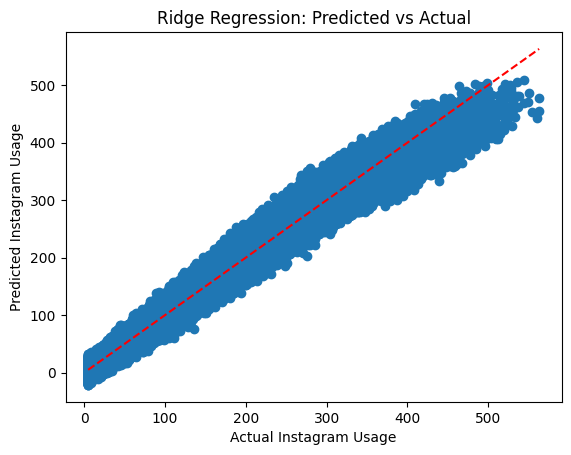

In [50]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Instagram Usage")
plt.ylabel("Predicted Instagram Usage")
plt.title("Ridge Regression: Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # reference line
plt.show()